<h1 style="text-align: center;">Customer Churn Prediction for Interconnect</h1>

This project develops a machine learning model to predict customer churn at Interconnect using contract, service, and billing information. ROC-AUC is used as the main evaluation metric, with the goal of surpassing a score of 0.88 on the test set.

The first stage focuses on preprocessing and exploratory analysis of the four datasets. Missing values, duplicate records, and repeated customer identifiers are verified. The data type of each column is also reviewed, and additional variables are created for later use during model training.

After validating the datasets, a merge operation is performed to build a single dataframe. This dataframe is then used to analyze patterns related to customer churn, such as customer tenure distribution, the most common contract types among customers who cancel the service, and the relationship between different services and churn rate.

A dummy model is later built as a baseline reference, and a CatBoost model is trained. During this stage, feature engineering and hyperparameter optimization are performed to improve the ROC-AUC metric and identify a model capable of surpassing the project target.

## Initialization

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator, PercentFormatter

from ticks_configuration import setup_minor_ticks

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score


from catboost import CatBoostClassifier

from sklearn.dummy import DummyClassifier

In [2]:
df_contract = pd.read_csv("datasets/contract.csv", sep=",")
df_internet = pd.read_csv("datasets/internet.csv", sep=",")
df_personal = pd.read_csv("datasets/personal.csv", sep=",")
df_phone = pd.read_csv("datasets/phone.csv", sep=",")

## Data preprocessing

### Contract dataset analysis

In [3]:
print(df_contract.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   BeginDate         7043 non-null   str    
 2   EndDate           7043 non-null   str    
 3   Type              7043 non-null   str    
 4   PaperlessBilling  7043 non-null   str    
 5   PaymentMethod     7043 non-null   str    
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   str    
dtypes: float64(1), str(7)
memory usage: 440.3 KB
None


In [4]:
display(df_contract.head())

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [5]:
df_contract.columns = df_contract.columns.str.strip().str.lower()
print(f"Columns in df_contract DataFrame: {df_contract.columns.tolist()}")

Columns in df_contract DataFrame: ['customerid', 'begindate', 'enddate', 'type', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges']


In [6]:
df_contract['begindate'] = pd.to_datetime(df_contract['begindate'], format='%Y-%m-%d', errors='coerce')

The `begindate` column is converted to the `datetime64[us]` type to correctly represent dates.

In [7]:
print(f"Unique values in 'enddate': {df_contract['enddate'].unique().tolist()}")

Unique values in 'enddate': ['No', '2019-12-01 00:00:00', '2019-11-01 00:00:00', '2019-10-01 00:00:00', '2020-01-01 00:00:00']


In [8]:
print("Number of active customers:", (df_contract['enddate'] == 'No').sum())
df_contract['churn'] = (df_contract['enddate'] != 'No').astype(int)
print("Number of active customers after conversion:", (df_contract['churn'] == 0).sum())

Number of active customers: 5174
Number of active customers after conversion: 5174


There are 5 distinct values in the `enddate` column. Four correspond to service cancellation dates, while one corresponds to 'No', a value used for customers who remain active. For this reason, the `churn` column is added as a binary variable where 0 represents active customers and 1 represents customers who canceled the service.

In [9]:
df_contract['enddate'] = pd.to_datetime(df_contract['enddate'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

In [10]:
analysis_date = pd.to_datetime('2020-02-01')

df_contract['tenure_months'] = (
    (analysis_date.year - df_contract['begindate'].dt.year) * 12
    + (analysis_date.month - df_contract['begindate'].dt.month)
)

# df_contract['tenure_years'] = (
#     (analysis_date - df_contract['begindate']).dt.days / 365
# )

# df_contract['tenure_days'] = (
#     (analysis_date - df_contract['begindate']).dt.days
# )

The `enddate` column is converted to a date format, and the `tenure_months` column is created to store the number of months a customer remained subscribed to the service before canceling or, if still active, until the dataset cutoff date.

In [11]:
print(f"Unique values in the 'type' column: {df_contract['type'].unique().tolist()}")

Unique values in the 'type' column: ['Month-to-month', 'One year', 'Two year']


In [12]:
print(f"Unique values in the 'paperlessbilling' column: {df_contract['paperlessbilling'].unique().tolist()}")

Unique values in the 'paperlessbilling' column: ['Yes', 'No']


In [13]:
print(f"Unique values in the 'paymentmethod' column: {df_contract['paymentmethod'].unique().tolist()}")

Unique values in the 'paymentmethod' column: ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']


In [14]:
print(f"Descriptive statistics for the 'monthlycharges' column:\n {df_contract['monthlycharges'].describe().round(2)}")

Descriptive statistics for the 'monthlycharges' column:
 count    7043.00
mean       64.76
std        30.09
min        18.25
25%        35.50
50%        70.35
75%        89.85
max       118.75
Name: monthlycharges, dtype: float64


In [15]:
display(df_contract[df_contract['begindate'] == '2020-02-01'])

,customerid,begindate,enddate,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_months
488,4472-LVYGI,2020-02-01,NaT,Two year,Yes,Bank transfer (automatic),52.55,,0,0
753,3115-CZMZD,2020-02-01,NaT,Two year,No,Mailed check,20.25,,0,0
936,5709-LVOEQ,2020-02-01,NaT,Two year,No,Mailed check,80.85,,0,0
1082,4367-NUYAO,2020-02-01,NaT,Two year,No,Mailed check,25.75,,0,0
1340,1371-DWPAZ,2020-02-01,NaT,Two year,No,Credit card (automatic),56.05,,0,0
3331,7644-OMVMY,2020-02-01,NaT,Two year,No,Mailed check,19.85,,0,0
3826,3213-VVOLG,2020-02-01,NaT,Two year,No,Mailed check,25.35,,0,0
4380,2520-SGTTA,2020-02-01,NaT,Two year,No,Mailed check,20.00,,0,0
5218,2923-ARZLG,2020-02-01,NaT,One year,Yes,Mailed check,19.70,,0,0
6670,4075-WKNIU,2020-02-01,NaT,Two year,No,Mailed check,73.35,,0,0


In [16]:

df_contract['totalcharges'] = pd.to_numeric(df_contract['totalcharges'], errors='coerce')

In [17]:
df_contract['totalcharges'] = df_contract['totalcharges'].fillna(0)

The `totalcharges` column is converted to float. There were 11 empty cells corresponding to contracts that started during the same month the data was extracted, meaning they did not yet have accumulated charges. For this reason, the missing values are replaced with 0.

In [18]:
print(f"Descriptive statistics for the 'totalcharges' column:\n {df_contract['totalcharges'].describe().round(2)}")

Descriptive statistics for the 'totalcharges' column:
 count    7043.00
mean     2279.73
std      2266.79
min         0.00
25%       398.55
50%      1394.55
75%      3786.60
max      8684.80
Name: totalcharges, dtype: float64


In [19]:
df_contract.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerid        7043 non-null   str           
 1   begindate         7043 non-null   datetime64[us]
 2   enddate           1869 non-null   datetime64[us]
 3   type              7043 non-null   str           
 4   paperlessbilling  7043 non-null   str           
 5   paymentmethod     7043 non-null   str           
 6   monthlycharges    7043 non-null   float64       
 7   totalcharges      7043 non-null   float64       
 8   churn             7043 non-null   int64         
 9   tenure_months     7043 non-null   int32         
dtypes: datetime64[us](2), float64(2), int32(1), int64(1), str(4)
memory usage: 522.9 KB


In [20]:
print(f"Total duplicated rows: {df_contract.duplicated().sum()}")
print(f"Duplicated entries in the 'customerid' column: {df_contract['customerid'].duplicated().sum()}")

Total duplicated rows: 0
Duplicated entries in the 'customerid' column: 0


The columns in `df_contract` now have data types consistent with the information they contain. In addition, it was verified that there are no duplicated observations or repeated user identifiers.

---
### Internet services dataset analysis

In [21]:
print(df_internet.info())

<class 'pandas.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        5517 non-null   str  
 1   InternetService   5517 non-null   str  
 2   OnlineSecurity    5517 non-null   str  
 3   OnlineBackup      5517 non-null   str  
 4   DeviceProtection  5517 non-null   str  
 5   TechSupport       5517 non-null   str  
 6   StreamingTV       5517 non-null   str  
 7   StreamingMovies   5517 non-null   str  
dtypes: str(8)
memory usage: 344.9 KB
None


In [22]:
display(df_internet.head())

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [23]:
df_internet.columns = df_internet.columns.str.strip().str.lower()
print(df_internet.columns.tolist())

['customerid', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies']


In [24]:
for column in df_internet.columns.drop('customerid'):
    print(f"Unique values in '{column}': {df_internet[column].unique().tolist()}")
    print()

Unique values in 'internetservice': ['DSL', 'Fiber optic']

Unique values in 'onlinesecurity': ['No', 'Yes']

Unique values in 'onlinebackup': ['Yes', 'No']

Unique values in 'deviceprotection': ['No', 'Yes']

Unique values in 'techsupport': ['No', 'Yes']

Unique values in 'streamingtv': ['No', 'Yes']

Unique values in 'streamingmovies': ['No', 'Yes']



The categorical columns in the internet services dataset do not contain missing values, empty strings, or categories other than Yes, No, DSL, and Fiber optic, so no additional preprocessing is required.

In [25]:
print(f"Duplicated rows in df_internet: {df_internet.duplicated().sum()}")
print(f"Duplicated identifiers in the 'customerid' column of df_internet: {df_internet['customerid'].duplicated().sum()}")

Duplicated rows in df_internet: 0
Duplicated identifiers in the 'customerid' column of df_internet: 0


The columns in the internet services dataset have data types consistent with the information they contain. In addition, it was verified that there are no duplicated observations or repeated user identifiers.

---
### Customer personal information dataset analysis

In [26]:
print(df_personal.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     7043 non-null   str  
 1   gender         7043 non-null   str  
 2   SeniorCitizen  7043 non-null   int64
 3   Partner        7043 non-null   str  
 4   Dependents     7043 non-null   str  
dtypes: int64(1), str(4)
memory usage: 275.2 KB
None


In [27]:
display(df_personal.head())

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [28]:
df_personal.columns = df_personal.columns.str.strip().str.lower()
print(f"Columns in df_personal: {df_personal.columns.tolist()}")

Columns in df_personal: ['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents']


In [29]:
for column in df_personal.columns.drop('customerid'):
    print(f"Unique values in {column}: {df_personal[column].unique().tolist()}")

Unique values in gender: ['Female', 'Male']
Unique values in seniorcitizen: [0, 1]
Unique values in partner: ['Yes', 'No']
Unique values in dependents: ['No', 'Yes']


There are no missing values, and the categorical columns contain only binary values.

In [30]:
print(f"Duplicated rows in df_personal: {df_personal.duplicated().sum()}")
print(f"Duplicated identifiers in the 'customerid' column of df_personal: {df_personal['customerid'].duplicated().sum()}")

Duplicated rows in df_personal: 0
Duplicated identifiers in the 'customerid' column of df_personal: 0


The columns in the customer personal information dataset have data types consistent with the information they contain. In addition, it was verified that there are no duplicated observations or repeated user identifiers.

---
### Phone services dataset analysis

In [31]:
print(df_phone.info())

<class 'pandas.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     6361 non-null   str  
 1   MultipleLines  6361 non-null   str  
dtypes: str(2)
memory usage: 99.5 KB
None


In [32]:
display(df_phone.head())

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [33]:
df_phone.columns = df_phone.columns.str.strip().str.lower()
print(f"Columns in df_phone: {df_phone.columns.tolist()}")

Columns in df_phone: ['customerid', 'multiplelines']


In [34]:
print(f"Total unique values in the 'multiplelines' column: {df_phone['multiplelines'].unique().tolist()}")

Total unique values in the 'multiplelines' column: ['No', 'Yes']


In [35]:
print(f"Duplicated rows in df_phone: {df_phone.duplicated().sum()}")
print(f"Duplicated identifiers in the 'customerid' column of df_phone: {df_phone['customerid'].duplicated().sum()}")

Duplicated rows in df_phone: 0
Duplicated identifiers in the 'customerid' column of df_phone: 0


The phone services dataset does not require additional preprocessing, as it contains no missing values, duplicated rows, or repeated user identifiers. In addition, it contains only one binary categorical column.

### Merging the datasets

The four datasets are merged using the `customerid` column to build a single dataframe that will be used for both exploratory analysis and predictive model training.

Although the cardinality of `df_contract['customerid']` and `df_personal['customerid']` is the same, it is verified that both sets of identifiers match before performing the merge.

In [36]:
if set(df_contract['customerid']) == set(df_personal['customerid']):
    print("Customer identifiers in df_contract and df_personal match.")

Customer identifiers in df_contract and df_personal match.


In [37]:
df_contract_personal = df_contract.merge(df_personal, on='customerid', how='left')

The dataset containing internet services information is added. Before performing the merge, it is verified that its customer identifiers are contained within the set of identifiers in the main dataframe.

In [38]:
if set(df_internet['customerid']).issubset(set(df_contract_personal['customerid'])):
    print("All customer identifiers from df_internet are present in df_contract_personal.")

All customer identifiers from df_internet are present in df_contract_personal.


In [39]:
df_contract_personal_internet = df_contract_personal.merge(df_internet, on='customerid', how='left')

The phone services dataset is now added. Before performing the merge, it is verified that its customer identifiers are contained in the dataframe that was just created.

In [40]:
if set(df_phone['customerid']).issubset(set(df_contract_personal_internet['customerid'])):
    print("All customer identifiers from df_phone are present in df_contract_personal_internet.")

All customer identifiers from df_phone are present in df_contract_personal_internet.


In [41]:
df_contract_personal_internet_phone = df_contract_personal_internet.merge(df_phone, on='customerid', how='left')

In [42]:
display(df_contract_personal_internet_phone.head())

,customerid,begindate,enddate,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_months,...,partner,dependents,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,multiplelines
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,...,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,0,34,...,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,1,4,...,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1840.75,0,45,...,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,1,5,...,No,No,Fiber optic,No,No,No,No,No,No,No


In [43]:
df_contract_personal_internet_phone.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerid        7043 non-null   str           
 1   begindate         7043 non-null   datetime64[us]
 2   enddate           1869 non-null   datetime64[us]
 3   type              7043 non-null   str           
 4   paperlessbilling  7043 non-null   str           
 5   paymentmethod     7043 non-null   str           
 6   monthlycharges    7043 non-null   float64       
 7   totalcharges      7043 non-null   float64       
 8   churn             7043 non-null   int64         
 9   tenure_months     7043 non-null   int32         
 10  gender            7043 non-null   str           
 11  seniorcitizen     7043 non-null   int64         
 12  partner           7043 non-null   str           
 13  dependents        7043 non-null   str           
 14  internetservice   5517 non-null   s

## Exploratory data analysis

In [44]:
print("Number of active customers and customers who canceled the service:")
print(df_contract_personal_internet_phone['churn'].value_counts())

print("\nProportion of active customers and customers who canceled the service:")
print(df_contract_personal_internet_phone['churn'].value_counts(normalize=True))

Number of active customers and customers who canceled the service:
churn
0    5174
1    1869
Name: count, dtype: int64

Proportion of active customers and customers who canceled the service:
churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


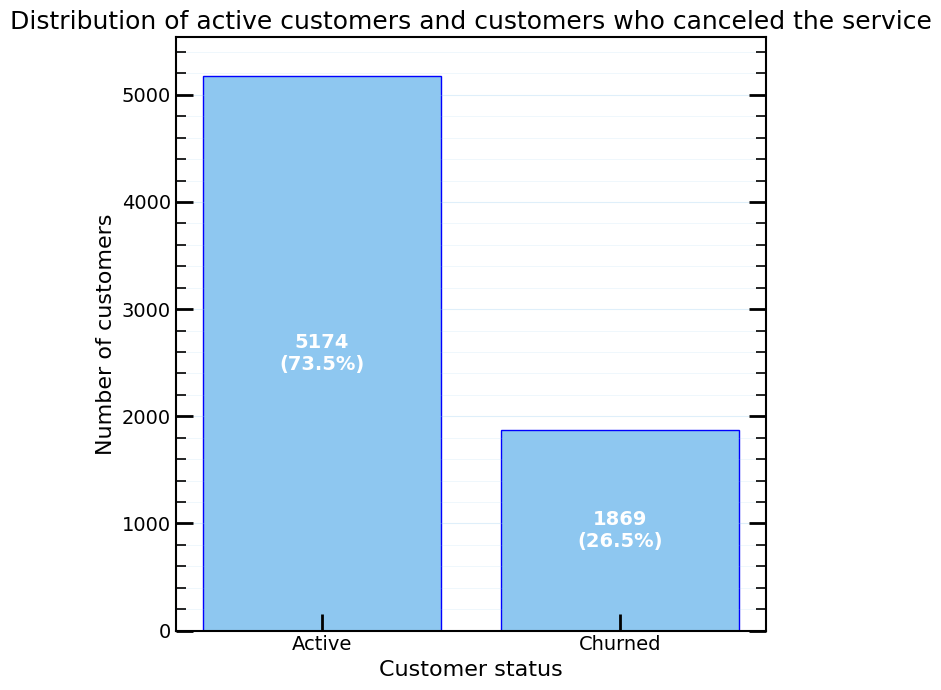

In [45]:
x = df_contract_personal_internet_phone['churn'].value_counts()
total = x.sum()

fig, ax = plt.subplots(figsize=(7, 7))

bars = ax.bar(x.index, x.values, edgecolor='blue', linewidth=1.0, color='#8EC7F0', alpha=1)

ax.set_xlabel('Customer status', fontsize=16)
ax.set_ylabel('Number of customers', fontsize=16)
ax.set_title('Distribution of active customers and customers who canceled the service', fontsize=18)

# Frame line width
for side in ['top', 'right', 'bottom', 'left']:
    ax.spines[side].set_linewidth(1.5)

ax.tick_params(labelsize=14)
ax.tick_params(axis='x', rotation=0)

ax.grid(axis='y', which='major', linewidth=0.8, alpha=0.28, color='#8EC7F0')
ax.grid(axis='y', which='minor', linewidth=0.5, alpha=0.20, color='#8EC7F0')

ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# Custom minor tick style
setup_minor_ticks(ax, x_minor_divisions=1, y_minor_divisions=5, major=(12, 2), minor=(7, 1.2), sides=dict(top=False, right=True, bottom=True, left=True),
    direction_top='in', direction_bottom='in', direction_left='in', direction_right='in')

# Count and percentage inside each bar
for p in bars:
    h = p.get_height()
    ax.annotate(
        f'{int(h)}\n({h / total:.1%})',
        (p.get_x() + p.get_width() / 2, h / 2),
        ha='center',
        va='center',
        color='white',
        fontsize=14,
        fontweight='bold'
    )

ax.set_xticks([0, 1])
ax.set_xticklabels(['Active', 'Churned'])
ax.set_ylim(0, max(x.values) * 1.07)

plt.tight_layout()
plt.show()

73.5% of customers remain active, while 26.5% canceled the service. The target variable is imbalanced across classes.

In [46]:
def plot_churn_distribution(df, feature):

    # Dictionary rename columns used for the plot
    feature_names = {
        'type': 'contract type',
        'paymentmethod': 'payment method',
        'internetservice': 'internet service',
        'seniorcitizen': 'senior citizen',
        'partner': 'partner',
        'multiplelines': 'multiple lines',
        'paperlessbilling': 'paperless billing',
        'dependents': 'dependents',
        'onlinesecurity': 'online security',
        'onlinebackup': 'online backup',
        'deviceprotection': 'device protection',
        'techsupport': 'tech support',
        'streamingtv': 'streaming TV',
        'streamingmovies': 'streaming movies'
    }

    # Dictionary to rename category values used for the plot
    category_labels = {
    'Yes': 'Yes',
    'No': 'No',
    'Fiber optic': 'Fiber optic',
    'DSL': 'DSL',
    'Month-to-month': 'Month-to-month',
    'One year': '1 year',
    'Two year': '2 years',
    'Electronic check': 'Electronic check',
    'Mailed check': 'Mailed check',
    'Bank transfer (automatic)': 'Bank transfer',
    'Credit card (automatic)': 'Credit card',
    0: 'No',
    1: 'Yes'
    }
    
    # Create a table with the proportion of active customers and customers who canceled the service for each category
    churn_table = pd.crosstab(df[feature], df['churn'], normalize='index')

    churn_table = churn_table.rename(columns={0: 'Active', 1: 'Churned'})

    x = np.arange(len(churn_table))

    active = churn_table['Active']
    churn = churn_table['Churned']

    fig, ax = plt.subplots(figsize=(10, 6))

    active_bars = ax.bar(x, active, edgecolor='#2E8B57', linewidth=1.0, color='#98FB98', alpha=1, label='Active')

    churn_bars = ax.bar(x, churn, bottom=active, edgecolor='#CC5500', linewidth=1.0, color='#FFB347', alpha=1, label='Churned')

    ax.set_xlabel(feature_names[feature].capitalize(), fontsize=12)

    ax.set_ylabel('Customer proportion', fontsize=12)

    ax.set_title(f'Customer proportion by {feature_names[feature]}', fontsize=16)

    ax.set_xticks(x)

    # Replace category names with readable labels
    ax.set_xticklabels([category_labels.get(v, v) for v in churn_table.index], rotation=0)

    ax.yaxis.set_major_formatter(PercentFormatter(1))

    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_linewidth(1.1)

    ax.tick_params(labelsize=10)

    ax.set_axisbelow(True)

    ax.grid(axis='y', which='major', linewidth=0.8, alpha=0.5, color="#8EC7F0")

    ax.grid(axis='y', which='minor', linewidth=0.5, alpha=0.3, color='#8EC7F0')

    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    setup_minor_ticks(ax, x_minor_divisions=1, y_minor_divisions=4, major=(8, 2), minor=(5, 1.2), sides=dict(top=False, right=True, bottom=True, left=True),
        direction_top='in', direction_bottom='out', direction_left='in', direction_right='in')

    # Percentage inside the active customer section
    for i, bar in enumerate(active_bars):
        h = bar.get_height()
        ax.annotate(
            f'{h:.1%}', (bar.get_x() + bar.get_width() / 2, h / 2),
            ha='center', va='center', color='#4B0082', fontsize=11)

    # Percentage inside the section of customers who canceled
    for i, bar in enumerate(churn_bars):
        h = bar.get_height()
        ax.annotate(
            f'{h:.1%}', (bar.get_x() + bar.get_width() / 2, active.iloc[i] + h / 2),
            ha='center', va='center', color='#4B0082', fontsize=11)

    ax.set_xlim(-0.75, len(x) - 0.25)
    ax.set_ylim(0, 1.2)

    ax.legend(loc='upper left', fontsize=11)

    plt.tight_layout()
    plt.show()

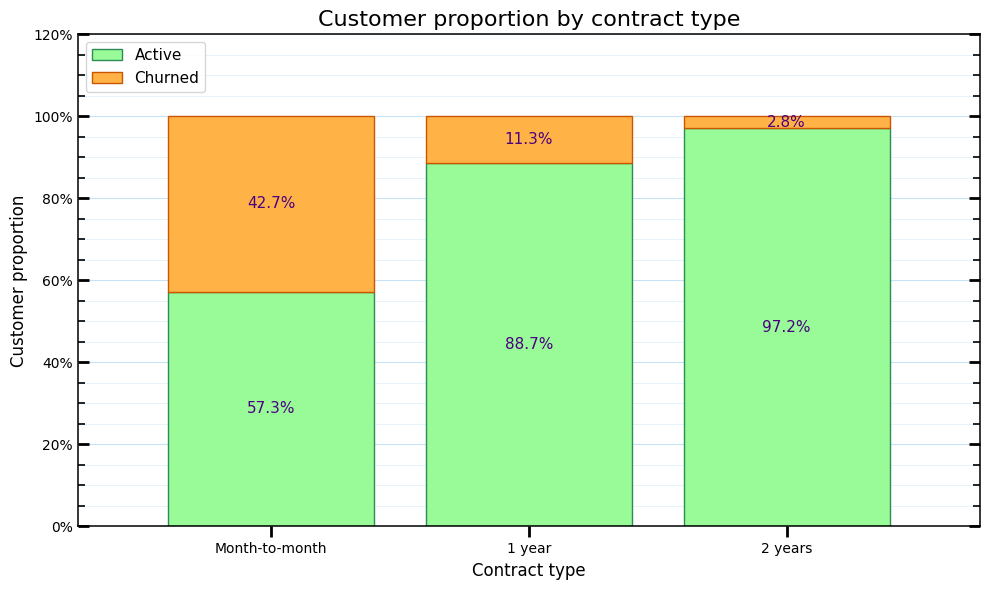

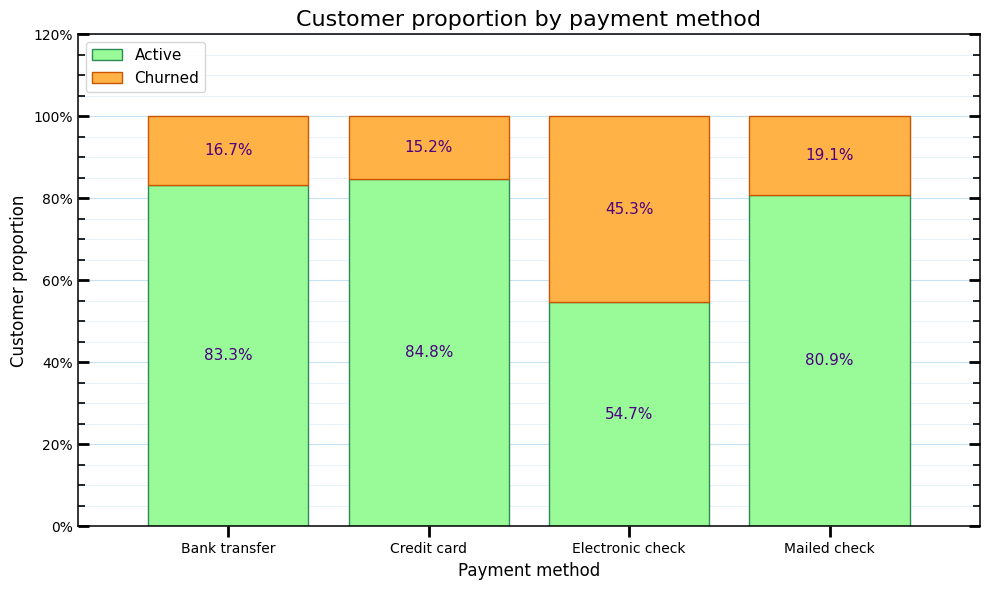

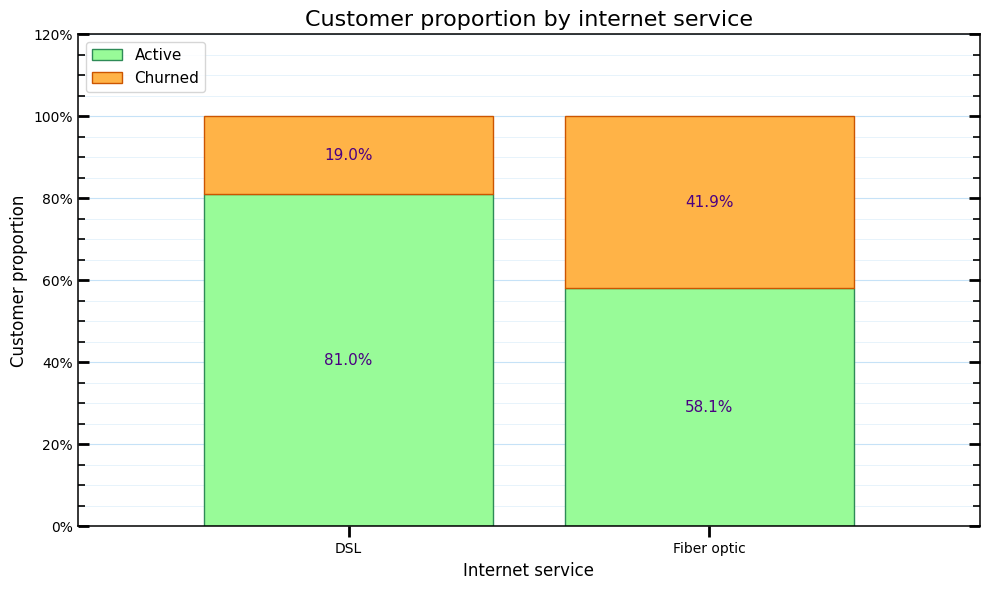

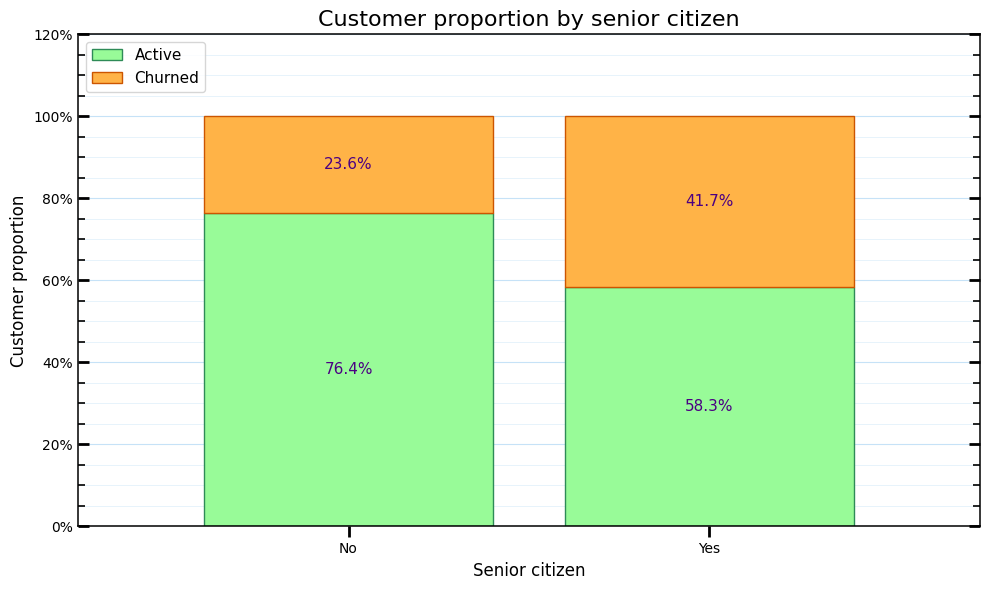

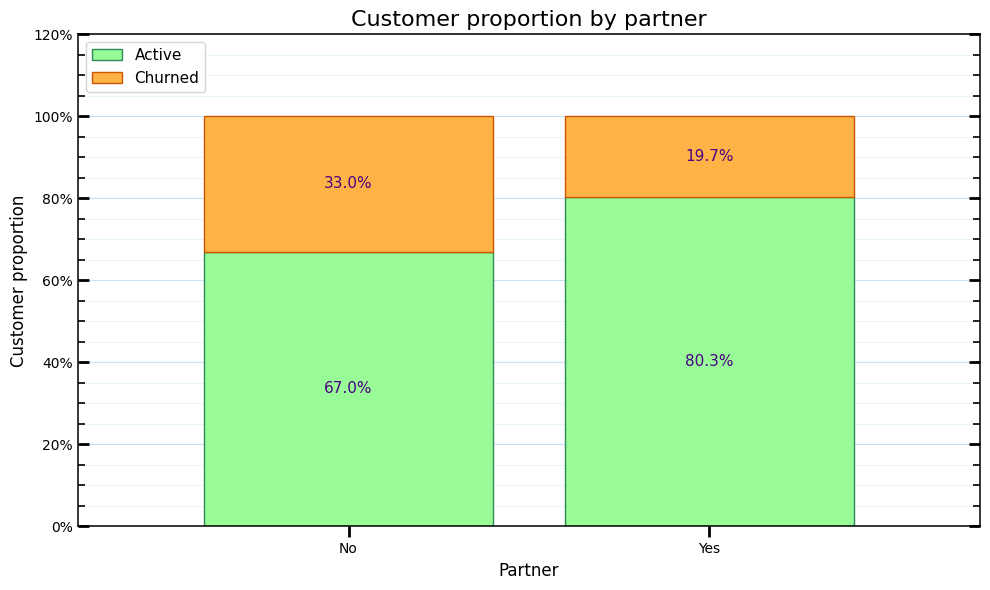

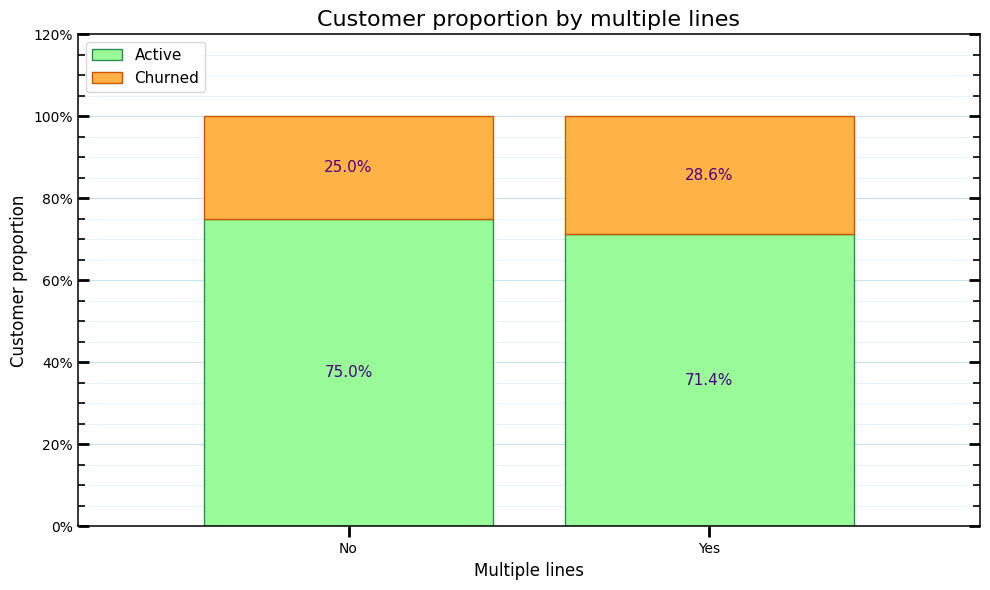

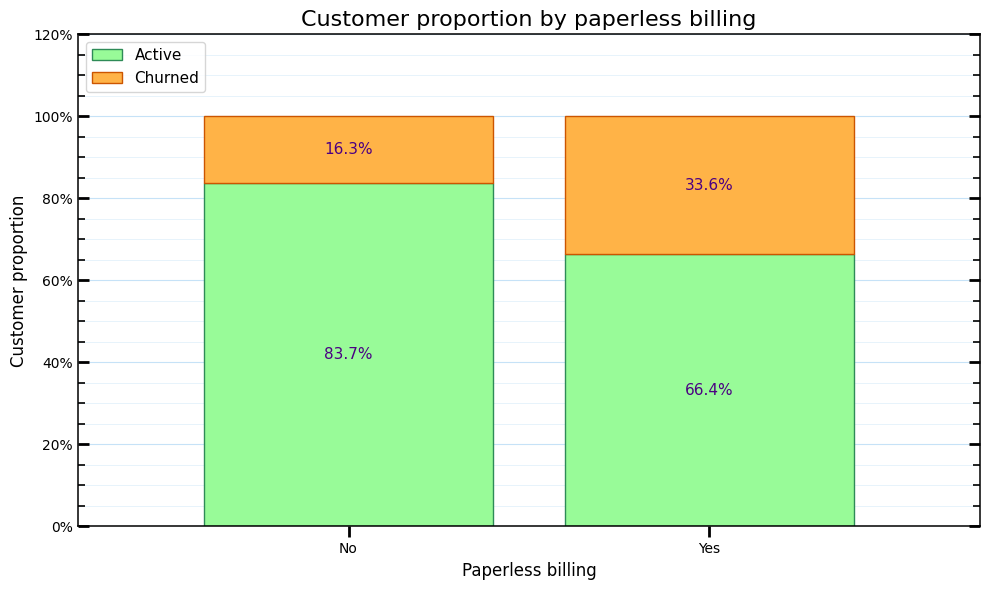

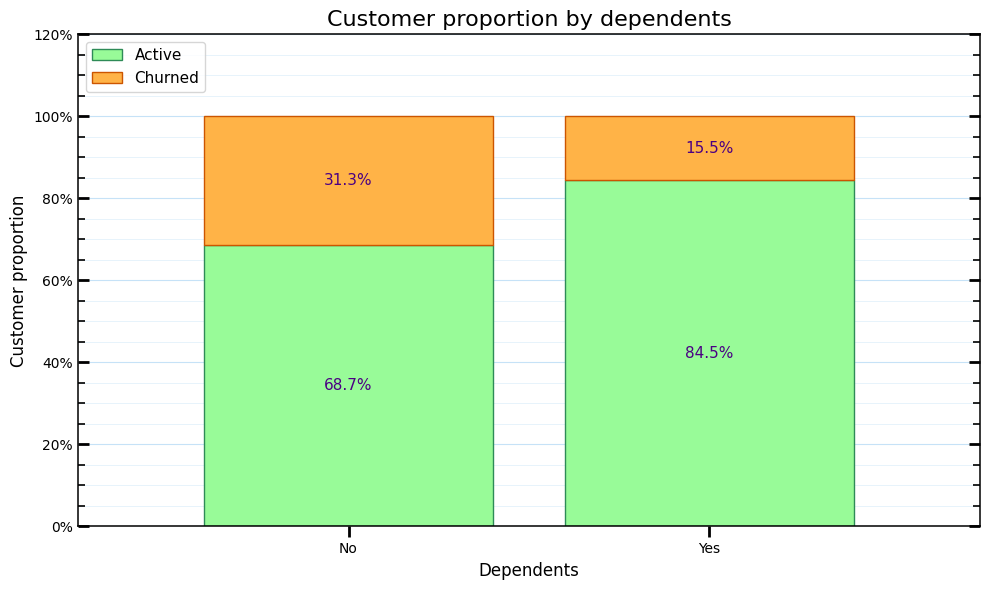

In [47]:
categorical_features = ['type', 'paymentmethod', 'internetservice', 'seniorcitizen', 'partner', 'multiplelines', 'paperlessbilling', 'dependents']

for feature in categorical_features:
    plot_churn_distribution(df_contract_personal_internet_phone, feature)

Customers with month-to-month contracts, electronic check payments, fiber optic service, and senior citizen status show a higher proportion of churn. A higher churn rate is also observed among customers without partners, without dependents, and with paperless billing, suggesting that these variables may provide relevant information during predictive model training.

On the other hand, variables such as multiple lines show smaller differences between categories, so they are likely to have a lower impact on customer churn prediction.

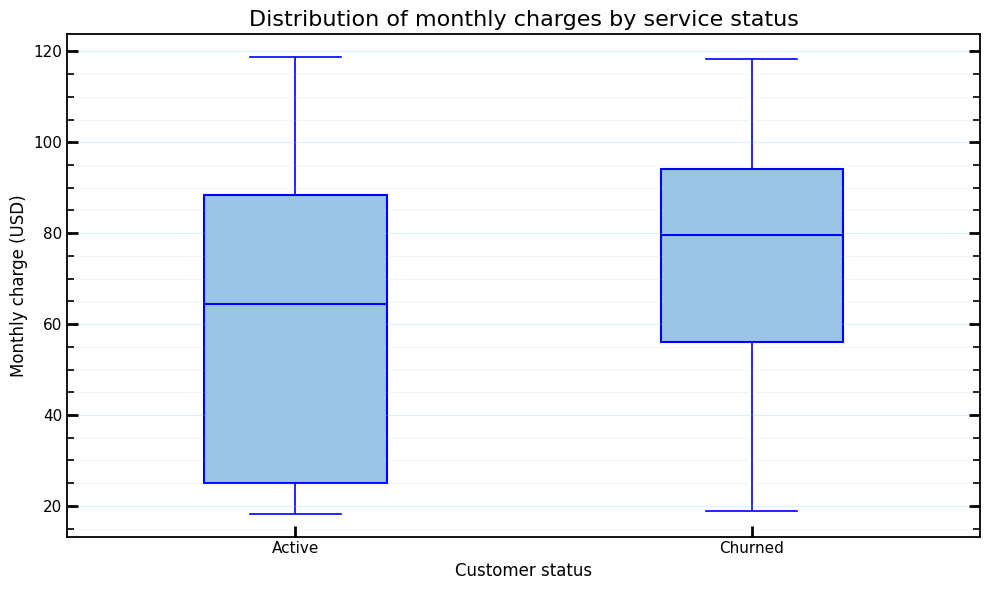

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df_contract_personal_internet_phone, x='churn', y='monthlycharges', ax=ax, width=0.4, color='#8EC7F0', linewidth=1.5,
    showfliers=True, boxprops=dict(edgecolor='blue'), whiskerprops=dict(color='blue', linewidth=1.2), capprops=dict(color='blue', linewidth=1.2),
    medianprops=dict(color='blue', linewidth=1.5), flierprops=dict( marker='o', markerfacecolor='#8EC7F0', markeredgecolor='blue', markersize=3,
                                                                   alpha=0.6, markeredgewidth=0.5)
)

ax.set_xlabel('Customer status', fontsize=12)
ax.set_ylabel('Monthly charge (USD)', fontsize=12)
ax.set_title('Distribution of monthly charges by service status', fontsize=16)

for side in ['top', 'right', 'bottom', 'left']:
    ax.spines[side].set_linewidth(1.3)

ax.tick_params(labelsize=11)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Active', 'Churned'])

ax.set_axisbelow(False)

ax.yaxis.set_minor_locator(AutoMinorLocator(2))

ax.grid(axis='y', which='major', linewidth=0.8, alpha=0.28, color='#8EC7F0')
ax.grid(axis='y', which='minor', linewidth=0.5, alpha=0.20, color='#8EC7F0')

setup_minor_ticks(ax, x_minor_divisions=1, y_minor_divisions=4, major=(8, 2), minor=(5, 1.2), sides=dict(top=False, right=True, bottom=True, left=True),
    direction_top='in', direction_bottom='in', direction_left='in', direction_right='in')

plt.tight_layout()
plt.show()

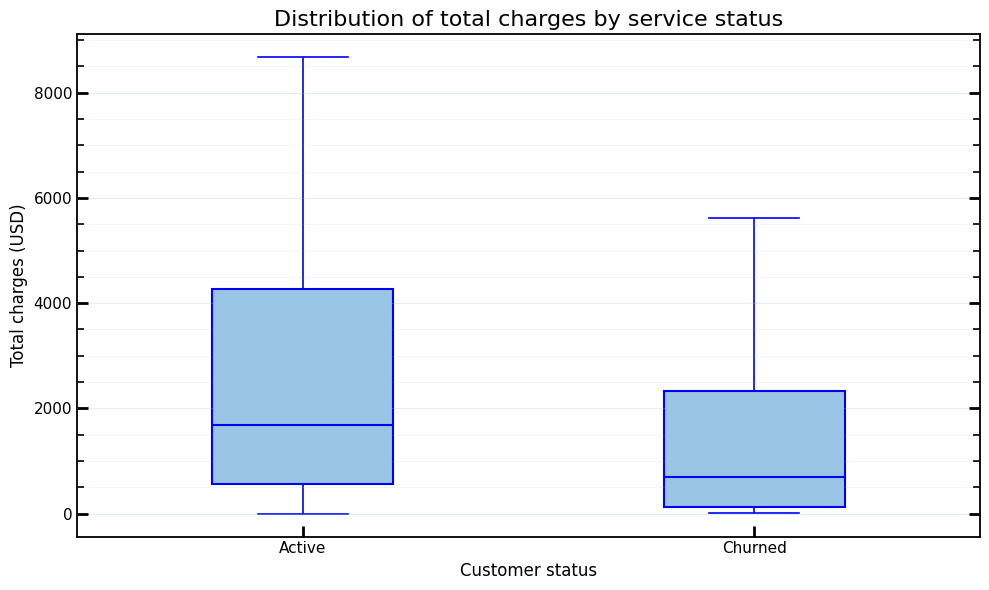

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df_contract_personal_internet_phone, x='churn', y='totalcharges', ax=ax, width=0.4, color='#8EC7F0', linewidth=1.5,
    showfliers=False, boxprops=dict(edgecolor='blue'), whiskerprops=dict(color='blue', linewidth=1.2), capprops=dict(color='blue', linewidth=1.2),
    medianprops=dict(color='blue', linewidth=1.5)
)

ax.set_xlabel('Customer status', fontsize=12)
ax.set_ylabel('Total charges (USD)', fontsize=12)
ax.set_title('Distribution of total charges by service status', fontsize=16)

for side in ['top', 'right', 'bottom', 'left']:
    ax.spines[side].set_linewidth(1.3)

ax.tick_params(labelsize=11)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Active', 'Churned'])

ax.set_axisbelow(False)

ax.yaxis.set_minor_locator(AutoMinorLocator(2))

ax.grid(axis='y', which='major', linewidth=0.8, alpha=0.28, color='#8EC7F0')
ax.grid(axis='y', which='minor', linewidth=0.5, alpha=0.20, color='#8EC7F0')

setup_minor_ticks(ax, x_minor_divisions=1, y_minor_divisions=4, major=(8, 2), minor=(5, 1.2), sides=dict(top=False, right=True, bottom=True, left=True),
    direction_top='in', direction_bottom='in', direction_left='in', direction_right='in')

plt.tight_layout()
plt.show()

Customers who canceled the service generally have higher monthly charges than active customers. On the other hand, active customers tend to accumulate higher total charges, which could be explained by a longer time subscribed to the service.

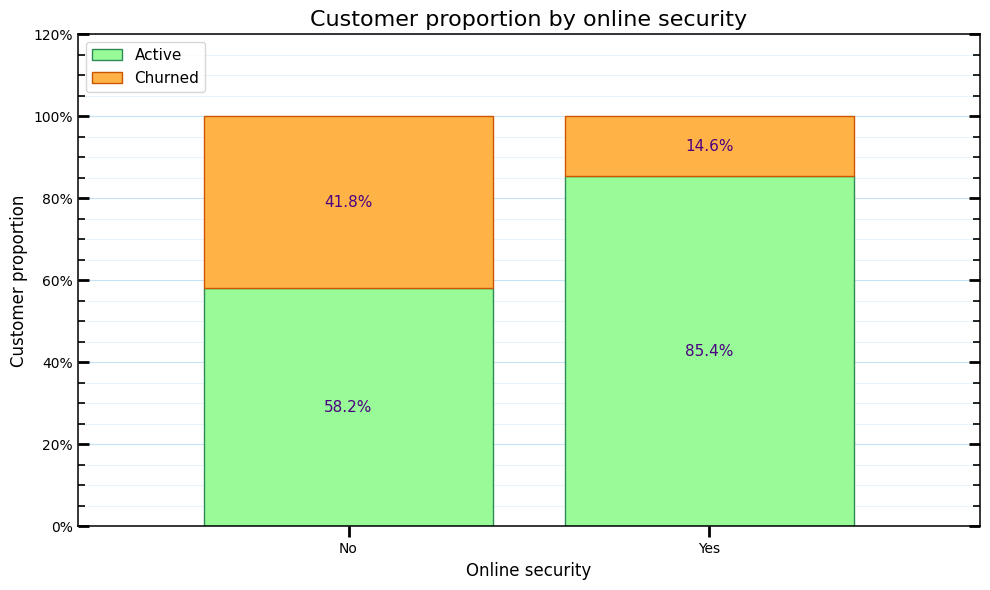

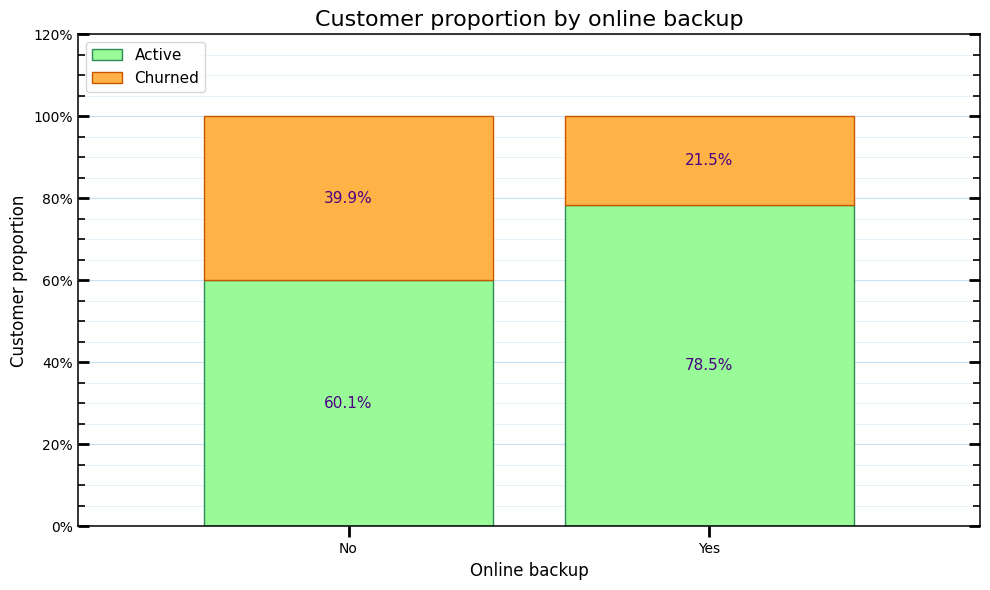

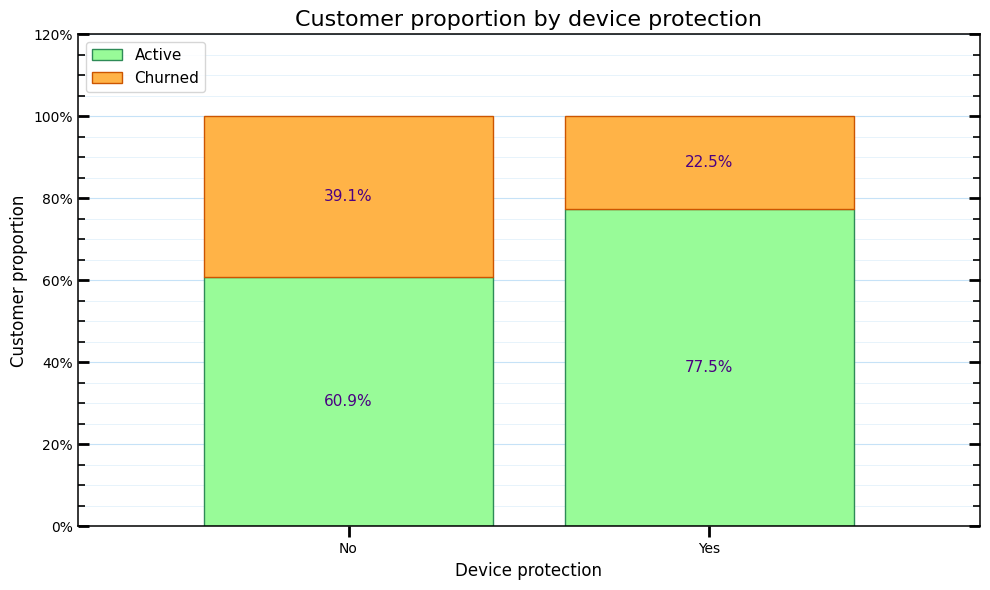

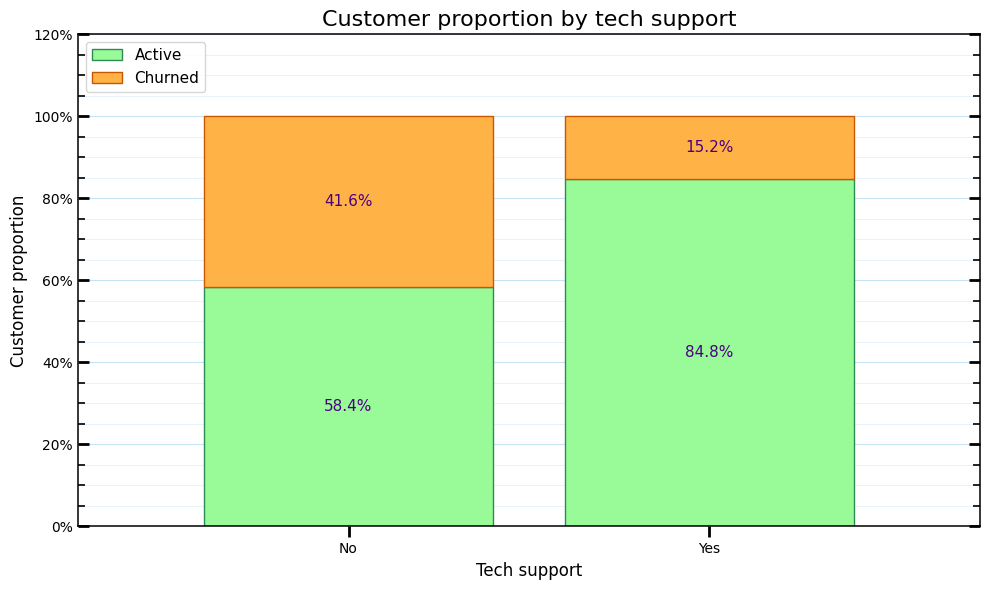

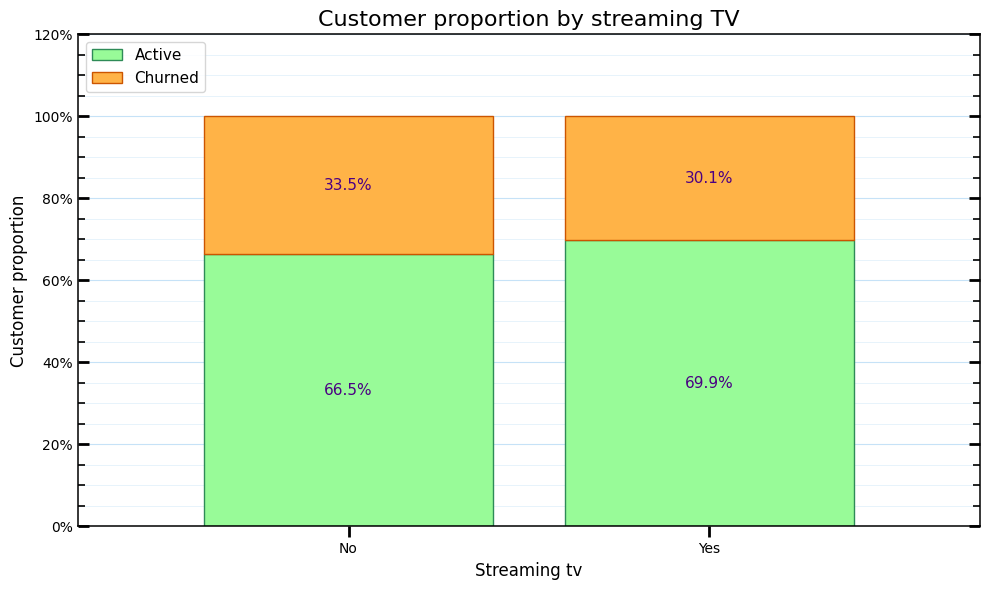

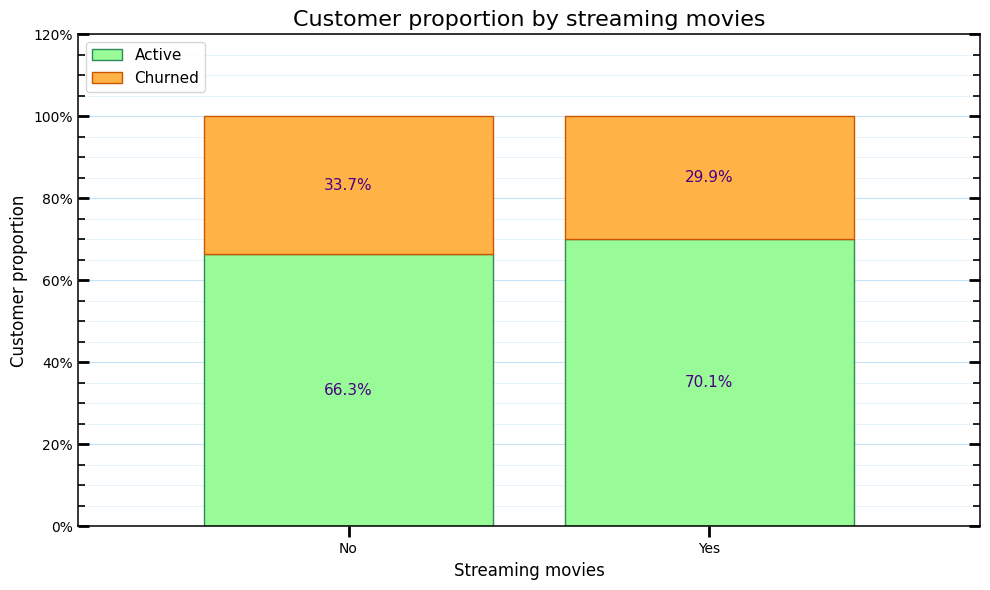

In [50]:
extra_services = [
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies'
]

for service in extra_services:
    plot_churn_distribution(df_contract_personal_internet_phone, service)

Customers without online security, online backup, device protection, or tech support show a higher proportion of churn. On the other hand, services such as streaming TV and streaming movies show smaller differences between categories, so these variables may have a lower impact during model training.

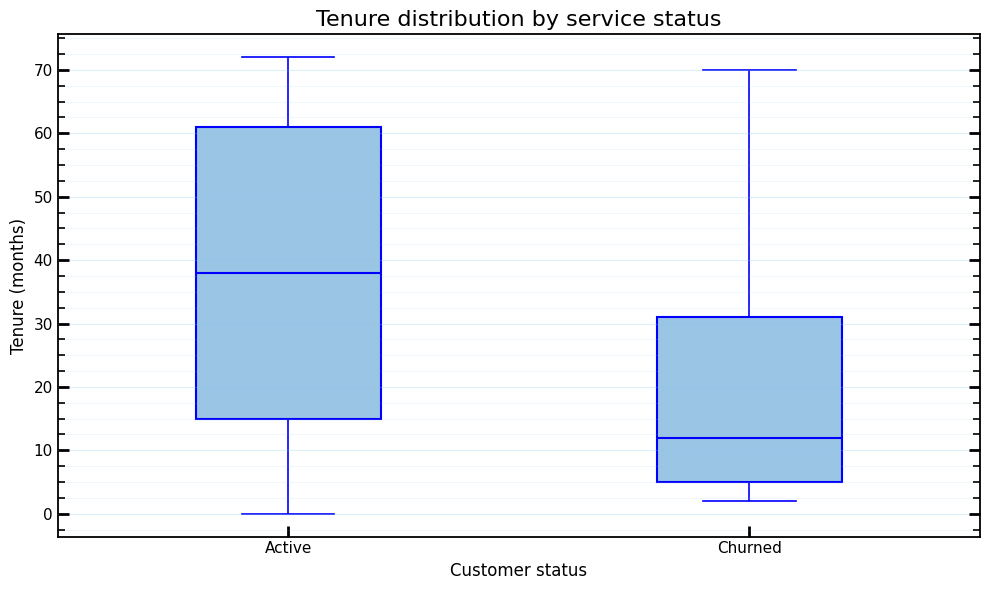

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df_contract_personal_internet_phone, x='churn', y='tenure_months', ax=ax, width=0.4, color='#8EC7F0', linewidth=1.5,
    showfliers=False, boxprops=dict(edgecolor='blue'), whiskerprops=dict(color='blue', linewidth=1.2), capprops=dict(color='blue', linewidth=1.2),
    medianprops=dict(color='blue', linewidth=1.5)
)

ax.set_xlabel('Customer status', fontsize=12)
ax.set_ylabel('Tenure (months)', fontsize=12)
ax.set_title('Tenure distribution by service status', fontsize=16)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Active', 'Churned'])

for side in ['top', 'right', 'bottom', 'left']:
    ax.spines[side].set_linewidth(1.3)

ax.tick_params(labelsize=11)

ax.set_axisbelow(False)

ax.yaxis.set_minor_locator(AutoMinorLocator(2))

ax.grid(axis='y', which='major', linewidth=0.8, alpha=0.28, color='#8EC7F0')
ax.grid(axis='y', which='minor', linewidth=0.5, alpha=0.20, color='#8EC7F0')

setup_minor_ticks(ax, x_minor_divisions=1, y_minor_divisions=4, major=(8, 2), minor=(5, 1.2), sides=dict(top=False, right=True, bottom=True, left=True),
    direction_top='in', direction_bottom='in', direction_left='in', direction_right='in')

plt.tight_layout()
plt.show()

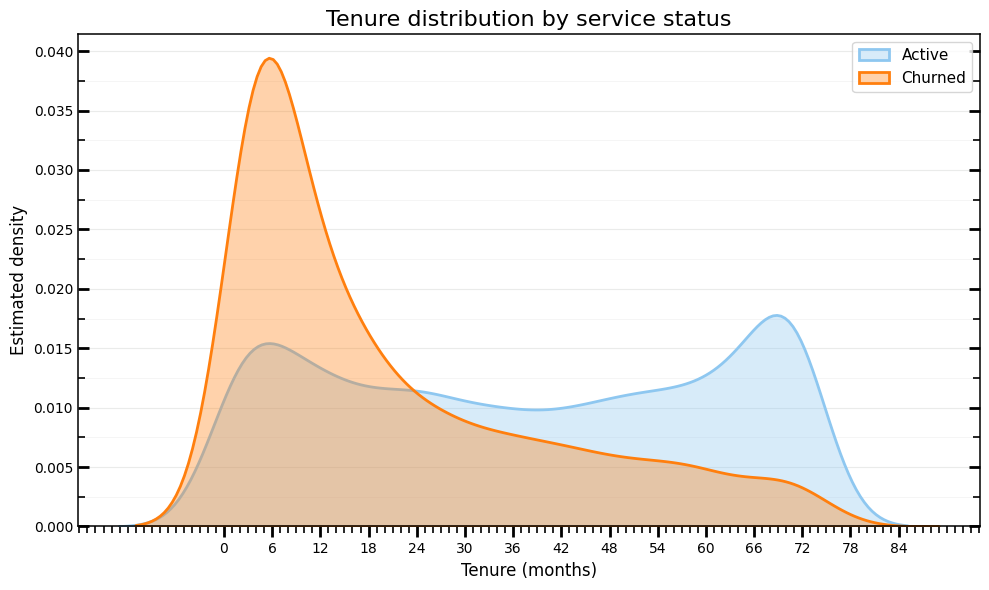

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(data=df_contract_personal_internet_phone[df_contract_personal_internet_phone['churn'] == 0],
    x='tenure_months', fill=True, color='#8EC7F0', linewidth=2, alpha=0.35, label='Active', ax=ax)

sns.kdeplot(data=df_contract_personal_internet_phone[df_contract_personal_internet_phone['churn'] == 1],
    x='tenure_months', fill=True, color='#FF7F0E', linewidth=2, alpha=0.35, label='Churned', ax=ax)

ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('Estimated density', fontsize=12)

ax.set_title('Tenure distribution by service status', fontsize=16)

for side in ['top', 'right', 'bottom', 'left']:
    ax.spines[side].set_linewidth(1.1)

ax.tick_params(labelsize=10)
ax.set_xticks(np.arange(0, 85, 6))

ax.set_axisbelow(True)

ax.grid(axis='y', which='major', linewidth=0.8, alpha=0.3, color="#BBBEBA")
ax.grid(axis='y', which='minor', linewidth=0.5, alpha=0.2, color='#BBBEBA')

ax.yaxis.set_minor_locator(AutoMinorLocator(2))

setup_minor_ticks(ax, x_minor_divisions=6, y_minor_divisions=2, major=(8, 2), minor=(5, 1.2), sides=dict(top=False, right=True, bottom=True, left=True),
    direction_top='in', direction_bottom='out', direction_left='in', direction_right='in')

ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

Customers who canceled the service tend to have lower tenure, with a median close to 10 months and a higher concentration during the first months of service. In contrast, active customers show a more stable distribution, with a local maximum at higher tenure values. This suggests that the probability of churn decreases as customer tenure increases, making this variable potentially especially useful during predictive model training.

## Model training and evaluation

### Feature engineering

New variables are created to capture patterns related to customer churn, such as the number of subscribed services, customer tenure, and other related characteristics.

In [53]:
services = ['onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies']

# Number of additional subscribed services
df_contract_personal_internet_phone['num_services'] = ((df_contract_personal_internet_phone[services] == 'Yes').sum(axis=1))

# Indicates whether the customer has internet service
df_contract_personal_internet_phone['internet'] = (~df_contract_personal_internet_phone['internetservice'].isna()).astype(int)

# Indicates whether the customer is new (tenure less than or equal to 6 months)
df_contract_personal_internet_phone['new_customer'] = (df_contract_personal_internet_phone['tenure_months'] <= 6).astype(int)

# Indicates whether the customer has 3 or more additional subscribed services
df_contract_personal_internet_phone['many_extra_services'] = (df_contract_personal_internet_phone['num_services'] >= 3).astype(int)

# Indicates whether the customer has a month-to-month contract
df_contract_personal_internet_phone['month_to_month'] = (df_contract_personal_internet_phone['type'] == 'Month-to-month').astype(int)

# Indicates whether the customer uses electronic check as payment method
df_contract_personal_internet_phone['electronic_check'] = (df_contract_personal_internet_phone['paymentmethod'] == 'Electronic check').astype(int)

In [54]:
random_state = 1997

# Define the features that the model will use to predict the target variable 'churn'
feature_names = ['type', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'tenure_months', 'totalcharges', 'gender', 'seniorcitizen',
    'partner', 'dependents', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport','streamingtv',
    'streamingmovies', 'multiplelines', 'num_services', 'internet', 'new_customer', 'many_extra_services']

# Categorical variables used to train the model
categorical_features = ['type', 'paperlessbilling', 'paymentmethod', 'gender', 'seniorcitizen', 'partner', 'dependents', 'internetservice',
    'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport','streamingtv', 'streamingmovies', 'multiplelines', 'internet', 'new_customer', 'many_extra_services']

# Variables containing missing values that will be treated as an additional category called 'missing'
missing_features = ['internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'multiplelines']

# Split features and target
features_cat = df_contract_personal_internet_phone[feature_names].copy()
target_cat = df_contract_personal_internet_phone['churn']

# Fill missing values in categorical features with the category 'missing'
for col in missing_features:
    features_cat[col] = features_cat[col].fillna('missing')

# Split the training, validation, and test sets into 60% - 20% - 20% respectively
features_train_cat, features_temp, target_train_cat, target_temp = train_test_split(features_cat, target_cat, test_size=0.40, random_state=random_state)
features_valid_cat, features_test_cat, target_valid_cat, target_test_cat = train_test_split(features_temp, target_temp, test_size=0.5, random_state=random_state)

## Dummy Model

A dummy model is built that always predicts the most frequent class in the dataset.

In [55]:
# Dummy classifier model used as a baseline reference
dummy_model = DummyClassifier(strategy='most_frequent',random_state=random_state)

dummy_model.fit(features_train_cat, target_train_cat)

dummy_predictions = dummy_model.predict(features_test_cat)

dummy_probabilities = dummy_model.predict_proba(features_test_cat)[:, 1]

dummy_roc_auc = roc_auc_score(target_test_cat, dummy_probabilities)

dummy_accuracy = accuracy_score(target_test_cat, dummy_predictions)

print(f"Dummy ROC-AUC: {dummy_roc_auc:.4f}")
print(f"Dummy Accuracy: {dummy_accuracy:.4f}")

Dummy ROC-AUC: 0.5000
Dummy Accuracy: 0.7395


## CatBoost Model

In [56]:
# Function to find the hyperparameter combination that maximizes validation ROC-AUC for the CatBoostClassifier model

def find_best_catboost_classifier_params(iter_range, lr_range, depth_range, l2_range, random_state,
    features_train, target_train, features_valid, target_valid, categorical_features):

    # Initialize evaluation metrics and hyperparameters to zero
    best_roc_auc = 0
    best_accuracy = 0
    best_iterations = 0
    best_learning_rate = 0
    best_depth = 0
    best_l2_leaf_reg = 0

    for iterations in iter_range:
        for learning_rate in lr_range:
            for depth in depth_range:
                for l2_leaf_reg in l2_range:
                    model = CatBoostClassifier(iterations=iterations, learning_rate=learning_rate, depth=depth, l2_leaf_reg=l2_leaf_reg,
                        loss_function='Logloss', eval_metric='AUC', class_weights=[1, 3],
                        random_state=random_state, verbose=False)

                    model.fit( features_train, target_train, cat_features=categorical_features, eval_set=(features_valid, target_valid),
                        early_stopping_rounds=50, use_best_model=True, verbose=False)

                    target_valid_proba = model.predict_proba(features_valid)[:, 1]
                    target_valid_predicted = (target_valid_proba >= 0.5).astype(int)

                    roc_auc = roc_auc_score(target_valid, target_valid_proba)
                    accuracy = accuracy_score(target_valid, target_valid_predicted)

                    if roc_auc > best_roc_auc:
                        best_roc_auc = roc_auc
                        best_accuracy = accuracy
                        best_iterations = iterations
                        best_learning_rate = learning_rate
                        best_depth = depth
                        best_l2_leaf_reg = l2_leaf_reg

    print(
        f"Best iterations: {best_iterations}, "
        f"Best learning rate: {best_learning_rate}, "
        f"Best depth: {best_depth}, "
        f"Best l2_leaf_reg: {best_l2_leaf_reg}, "
        f"Best ROC-AUC: {best_roc_auc:.4f}, "
        f"Accuracy: {best_accuracy:.4f}"
    )

    return (best_iterations, best_learning_rate, best_depth, best_l2_leaf_reg, best_roc_auc, best_accuracy)


# Train the best model and evaluate it on the test set
def evaluate_best_catboost_classifier(best_iterations, best_learning_rate, best_depth, best_l2_leaf_reg, random_state,
    features_train, target_train, features_test, target_test, categorical_features):

    best_model = CatBoostClassifier(iterations=best_iterations, learning_rate=best_learning_rate, depth=best_depth, l2_leaf_reg=best_l2_leaf_reg,
        loss_function='Logloss', eval_metric='AUC', class_weights=[1, 3], random_state=random_state, verbose=False)

    best_model.fit(features_train, target_train, cat_features=categorical_features, verbose=False)

    target_test_proba = best_model.predict_proba(features_test)[:, 1]
    target_test_predicted = (target_test_proba >= 0.5).astype(int)

    test_roc_auc = roc_auc_score(target_test, target_test_proba)

    test_accuracy = accuracy_score(target_test, target_test_predicted)

    print(f"Test set ROC-AUC: {test_roc_auc:.4f}")
    print(f"Test set Accuracy: {test_accuracy:.4f}")

    return test_roc_auc, test_accuracy, target_test_predicted, target_test_proba

In [57]:
# Search for the best hyperparameter combination for the CatBoostClassifier model using the validation set
best_params_catboost = find_best_catboost_classifier_params(iter_range=[300], lr_range=[0.08], depth_range=[4], l2_range=[4], random_state=random_state,
    features_train=features_train_cat, target_train=target_train_cat, features_valid=features_valid_cat, target_valid=target_valid_cat,
    categorical_features=categorical_features
)

# Evaluate the best model found on the test set
test_roc_auc, test_accuracy, test_pred, test_proba = evaluate_best_catboost_classifier(
    best_iterations=best_params_catboost[0], best_learning_rate=best_params_catboost[1], best_depth=best_params_catboost[2], best_l2_leaf_reg=best_params_catboost[3],
    random_state=random_state, features_train=features_train_cat, target_train=target_train_cat, features_test=features_test_cat, target_test=target_test_cat,
    categorical_features=categorical_features
)

Best iterations: 300, Best learning rate: 0.08, Best depth: 4, Best l2_leaf_reg: 4, Best ROC-AUC: 0.9027, Accuracy: 0.8226
Test set ROC-AUC: 0.9253
Test set Accuracy: 0.8311


The CatBoost model achieves considerably better performance, reaching a ROC-AUC of 0.9253 compared to 0.5 for the dummy model. This indicates that the model is able to correctly separate both classes and capture patterns related to customer churn.

## Conclusions

The CatBoost model achieves a ROC-AUC score of 0.9253 on the test set, surpassing the project target of 0.88.

Customer tenure is one of the variables with the greatest impact on churn prediction, consistent with the results observed during the exploratory analysis. Other engineered variables such as the number of subscribed services (`num_services`), whether the customer has internet service (`internet`), new customers (`new_customer`), and customers with multiple additional services (`many_extra_services`) also contribute to the model's performance.

The dummy model obtains a ROC-AUC of 0.5, while CatBoost reaches 0.9253, indicating that the model is able to identify patterns related to customer churn.

In conclusion, the developed model is viable for predicting customers at risk of churn and can be used to offer promotions or special plans aimed at customer retention.